What I have:
reactants: omol, matpes, svp, tzvp opt; + tzvp sp
products: omol, matpes, svp opt; + tzvp sp

Goal: compare the new method to traditional one (svp opt + tzvp sp).
Assumption: svp opt + tzvp sp predict accurate results.
!!! even its absolute energies is very bad. But the relative energies are good. => it has good adsorption energy.

1. compare new opt binding energies wrt tranditional method energies. If a method have similar binding energy to tzvp does, it is good in predicting binding energy.


Thus:
1. omol opt have the overall lowest sp energy. => omol opt structure is the most close one to tzvp minimum for both reactants and products. => omol is good, if we trust tzvp. (But we don't care about this, the only factor to be compared is the binding energy wrt to svp opt + tzvp sp!!!)
2. use all of svp opt + tzvp sp for both products and reactants as reference.
3. But the problem is more than one stable configurations are observed. And different methods predict different minima.
4. Moreover, I don't where the svp opt minima is. What I use is omol opt, then use the lowest energy configuration, and use it to preform svp opt further. And for matpes,  => Three methods fall in the same minima in most of times. but for some case, matpes opt show significantly higher energies.

In [21]:
from lzn.universal import to_path, eV_to_kJdmol
from lzn.parse_tore_mspa_out import exclude_unwanted_sites, parse_vs_tolist
from lzn.universal import parse_lzn_stem, hartree_to_eV
from parseName_extractEnergy import parseName_extractEnergy
from plot_with_regression import plot_with_regression

from ase.io import read
from copy import deepcopy

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sympy.printing.pretty.pretty_symbology import line_width

In [22]:
# General Info
ads_l = ["co", "h2s", "h2o", "nh3"]
opt_l = ["omol25_low_s", "matpes_r2scan", "pbe0_def2svp"]
site_index = [f"{i:02d}" for i in range(0, 22, 2) if i != 16]
pj_path = to_path("~/organized")

r_dict = {} # Reactants dict
p_dict = {} # Products dict


general_save = to_path("~/organized/901_data")

### Calculations

###### Reactants energies

In [23]:
# cluster energy
r_dict["c opt energy"] = np.array([[-205.957535, -401.687866, -11994.7539400 * hartree_to_eV]])
r_dict["c sp energy"] = np.array([[-11998.1881525, -11998.1802856, -11998.1874453]]) * hartree_to_eV

# adsorbates tzvp sp energies
sp_ll = [] # [opt1:[ads1, ads2, ...], ...]
for opti in ["omol25_low_s", "matpes_r2scan", "pbe0_def2svp"]:
    sp_l = []
    for adsi in ads_l:
        pathi = pj_path / "041_adsorbates_sp" / f"{adsi}_opt-{opti}_sp-pbe0_def2tzvp.log"
        atoms = read(pathi, index= -1, format="gaussian-out")
        atoms_energy = atoms.get_potential_energy()
        sp_l.append(atoms_energy)
    sp_ll.append(sp_l)
r_dict["a sp energy"] = np.array(sp_ll)

# adsorbates opt energies
opt_ll = []
for opti in ["omol25_low_s", "matpes_r2scan"]:
    opt_l = []
    for adsi in ads_l:
        pathi = pj_path / "04_adsorbates_mlip_opt" / f"{adsi}_opt-{opti}.traj"
        atoms = read(pathi, index= -1, format="traj")
        atoms_energy = atoms.get_potential_energy()
        opt_l.append(atoms_energy)
    opt_ll.append(opt_l)
opt_l = []
for adsi in ads_l:
    pathi = pj_path / "04_adsorbates_g16_opt" / f"{adsi}_opt-pbe0_def2svp.log"
    atoms = read(pathi, index= -1, format="gaussian-out")
    atoms_energy = atoms.get_potential_energy()
    opt_l.append(atoms_energy)
opt_ll.append(opt_l)

r_dict["a opt energy"] = np.array(opt_ll)

# sum reactants energies
r_dict["sum opt energy"] = r_dict["a opt energy"] + r_dict["c opt energy"].T
r_dict["sum sp energy"] = r_dict["a sp energy"] + r_dict["c sp energy"].T
print(r_dict["sum opt energy"])
print(r_dict["sum sp energy"])


[[-2.14251288e+02 -2.13695118e+02 -2.15298692e+02 -2.18760224e+02]
 [-4.18301460e+02 -4.16964817e+02 -4.17079851e+02 -4.22245018e+02]
 [-3.29471545e+05 -3.37254669e+05 -3.28469627e+05 -3.27929882e+05]]
[[-329568.665488   -337351.95226184 -328565.82506111 -328025.30003137]
 [-329568.44325485 -337351.73821121 -328565.61023105 -328025.08409144]
 [-329568.64496413 -337351.93167862 -328565.80344041 -328025.2747021 ]]


###### Reactants properties

In [24]:
# surface potential
cat_vmax_uni, _x = exclude_unwanted_sites(pj_path / "05_mspa_clusters" / "tio12CDa_opt-pbe0_def2tzvpS_hs.out")
cat_v = [i[2] for i in cat_vmax_uni]
r_dict["c vsmax"] = np.array(cat_v)

ads_v_names = [f"{i}S_hs.out" for i in ads_l]
get_ads_vmin = lambda ads_v_name: parse_vs_tolist(pj_path / "05_mspa_adsorbates" / ads_v_name, vs="min")[0][2]
ads_vmin = list(map(get_ads_vmin, ads_v_names))
r_dict["a vsmin"] = ads_vmin

###### Products energies

In [25]:
p_dict["opt name"] = ["omol25", "r2scan", "svp"]
p_dict["opt index"] = [0, 1, 2]

get_opt_path = lambda index_, key_: pj_path / f"77{str(index_)}_{key_}_opt"
get_sp_path = lambda index_, key_: pj_path / f"79{str(index_)}_{key_}_opt_sp"
p_dict["opt path"] = list(map(get_opt_path, p_dict["opt index"], p_dict["opt name"]))
p_dict["sp path"] = list(map(get_sp_path, p_dict["opt index"], p_dict["opt name"]))

p_dict["opt energy"] = list(map(parseName_extractEnergy, p_dict["opt path"]))
p_dict["sp energy"] = list(map(parseName_extractEnergy, p_dict["sp path"]))


omol25
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
r2scan
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
svp
10 matching files
13 matching files
11 matching files
10 matching files
10+10+10+10 energies extracted
omol25
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
r2scan
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted
svp
10 matching files
10 matching files
10 matching files
10 matching files
10+10+10+10 energies extracted


### Plot abs energies

In [26]:
print(p_dict["sp path"])
print(r_dict.keys())

[PosixPath('/home/zining/organized/790_omol25_opt_sp'), PosixPath('/home/zining/organized/791_r2scan_opt_sp'), PosixPath('/home/zining/organized/792_svp_opt_sp')]
dict_keys(['c opt energy', 'c sp energy', 'a sp energy', 'a opt energy', 'sum opt energy', 'sum sp energy', 'c vsmax', 'a vsmin'])


In [27]:
sp_Ep = p_dict["sp energy"]
sp_Er = r_dict["sum sp energy"]
sp_Ep

[array([[-329569.12319005, -329569.07438371, -329568.81641433,
         -329568.89602668, -329568.73348491, -329568.71018652,
         -329568.737036  , -329568.7701577 , -329568.65123305,
         -329568.65160585],
        [-337352.6859726 , -337352.60230031, -337352.42332014,
         -337352.35095146, -337352.24936864, -337352.17437134,
         -337352.23081319, -337352.21612721, -337352.08208664,
         -337352.06978437],
        [-328566.89951572, -328566.81626249, -328566.6176874 ,
         -328566.48867005, -328566.39084784, -328566.30266935,
         -328566.66501344, -328566.33230799, -328566.21679565,
         -328566.2024743 ],
        [-328026.74083352, -328026.65232304, -328026.38103913,
         -328026.24338489, -328026.09461208, -328026.07790429,
         -328026.48154711, -328026.1483845 , -328025.94140381,
         -328025.92408105]]),
 array([[-329568.91632638, -329568.87423036, -329568.68805006,
         -329568.57833919, -329568.52434908, -329568.50352965,
    

In [28]:
print((-11998.1802856 - 113.230991861)*hartree_to_eV)

sp_Er

-329568.444724091


array([[-329568.665488  , -337351.95226184, -328565.82506111,
        -328025.30003137],
       [-329568.44325485, -337351.73821121, -328565.61023105,
        -328025.08409144],
       [-329568.64496413, -337351.93167862, -328565.80344041,
        -328025.2747021 ]])

In [29]:
uniq_sites = list(range(0, 22 ,2))
uniq_sites.pop(-3)
print(uniq_sites)
print(len(uniq_sites))

[0, 2, 4, 6, 8, 10, 12, 14, 18, 20]
10


In [30]:
svptzvpr = np.array([-113.231244837, -399.261758223, -76.3774982905, -56.5134333793]) * hartree_to_eV
svptzvpr += -11998.1874453 * hartree_to_eV


-329568.4432548472
[-329568.91632638 -329568.87423036 -329568.68805006 -329568.57833919
 -329568.52434908 -329568.50352965 -329568.54003917 -329568.55774562
 -329568.43430933 -329568.42534045]

-329568.6654879988
[-329569.12319005 -329569.07438371 -329568.81641433 -329568.89602668
 -329568.73348491 -329568.71018652 -329568.737036   -329568.7701577
 -329568.65123305 -329568.65160585]

0.2017092810710892
[-0.27136225 -0.22926623 -0.04308593  0.06662494  0.12061505  0.14143448
  0.10492496  0.08721851  0.2106548   0.21962367]

-0.020523870538454503
[-0.47822593 -0.42941958 -0.1714502  -0.25106255 -0.08852078 -0.06522239
 -0.09207187 -0.12519357 -0.00626893 -0.00664172]


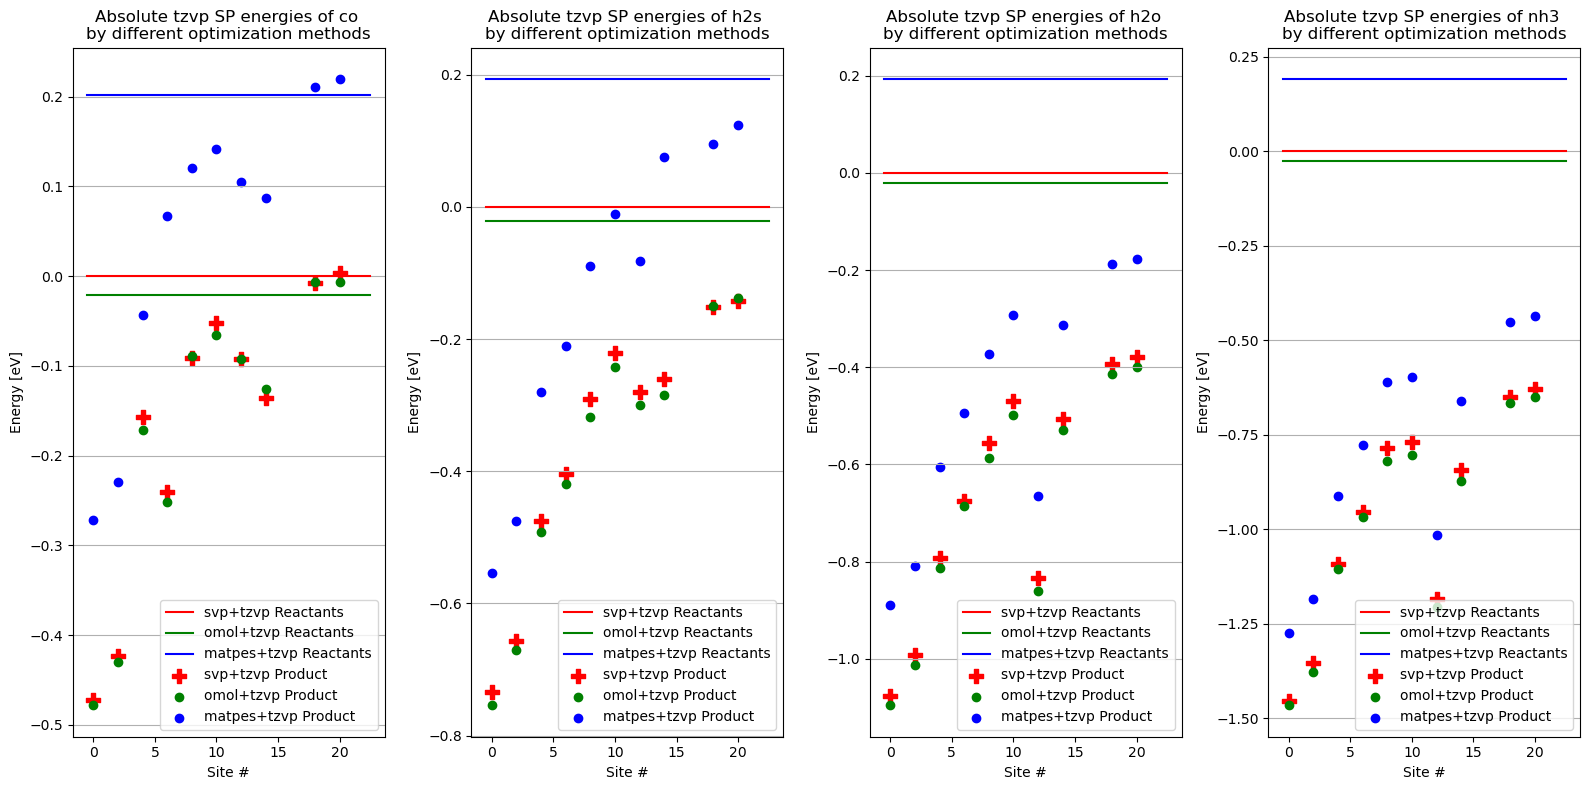

In [31]:
fig1 = plt.figure(1, figsize = (16,8))
gs = fig1.add_gridspec(1,4)

for i, ads_ in enumerate(ads_l):
    refr = sp_Er[2][i]

    svpr = svptzvpr[i] - refr
    omolr = sp_Er[0][i] - refr
    matpesr = sp_Er[1][i] - refr

    svpp = sp_Ep[2][i] - refr
    omolp = sp_Ep[0][i] - refr
    matpesp = sp_Ep[1][i] - refr

    if i == 0:
        print(sp_Er[1][i])
        print(sp_Ep[1][i])
        print()
        print(sp_Er[0][i])
        print(sp_Ep[0][i])
        print()
        print(matpesr)
        print(matpesp)
        print()
        print(omolr)
        print(omolp)

    gname = fig1.add_subplot(gs[0,i])
    gname.set_title(f"Absolute tzvp SP energies of {ads_} \n"
                    f"by different optimization methods")

    # gname.plot([-0.5, 22.5], [0.]*2, "k", label="tzvp+tzvp Reactants")
    gname.plot([-0.5, 22.5], [0.]*2, "r", label="svp+tzvp Reactants")
    gname.plot([-0.5, 22.5], [omolr]*2, "g", label="omol+tzvp Reactants")
    gname.plot([-0.5, 22.5], [matpesr]*2, "b", label="matpes+tzvp Reactants")

    gname.scatter(uniq_sites, svpp, c="r", s=100, marker="P", label="svp+tzvp Product")
    gname.scatter(uniq_sites, omolp, c="g", label="omol+tzvp Product")
    gname.scatter(uniq_sites, matpesp, c="b", label="matpes+tzvp Product")

    gname.grid(axis="y")
    gname.set_xlabel("Site #")
    gname.set_ylabel("Energy [eV]")
    gname.legend()

fig1.tight_layout()
fig1.savefig(general_save / "lgd_abs_sp.pdf")
plt.show()

###### Binding energies

### Demo: method's inherent energies

ref is svp+tzvp

In [32]:

# svp opt + tzvp sp as ref
ref_dE = (p_dict["sp energy"][2] - np.array([r_dict["sum sp energy"][2]]).T) * eV_to_kJdmol
print(ref_dE)

# iteration over all opt energies
# p_dict=opt*ads*sites; r_dict=opt*ads->opt*ads*1
array_dE = (np.array(p_dict["opt energy"]) - r_dict["sum opt energy"].reshape(3,4,1)) * eV_to_kJdmol

print(array_dE)


[[ -45.51795694  -40.85165766  -15.11599187  -23.21775653   -8.8147944
    -5.04457791   -8.94921994  -13.0502493    -0.76212657    0.37235152]
 [ -70.86613584  -63.39265309  -45.81021174  -39.01752086  -28.00670337
   -21.33189739  -27.06047354  -25.18297925  -14.66811851  -13.69064525]
 [-103.90838798  -95.66510893  -76.48137577  -65.14105816  -53.62351938
   -45.39809372  -80.36790186  -48.84563639  -37.93931376  -36.50579134]
 [-140.21959294 -130.73445289 -105.48292911  -92.05087649  -75.65279771
   -74.11504298 -114.29777927  -81.45961374  -62.66261656  -60.74390193]]
[[[ -40.34052126  -38.1041751   -22.26572084  -18.75146259  -13.28647447
    -10.93087614  -13.49258932  -21.71509973  -11.81128101  -12.10278631]
  [ -64.21469434  -60.59443416  -45.20648808  -44.78984163  -36.35091062
    -28.96758211  -29.56089844  -33.25771557  -26.88876659  -24.69806014]
  [-100.1142889   -97.96480542  -79.87233802  -73.15152154  -64.98348434
    -58.86334544  -87.46472588  -63.92493734  -52.501

###### Dataframe

In [33]:
f_dE = np.insert(array_dE, 0, ref_dE, axis=0)
print(f_dE.shape) # methods*abs*sites

x = r_dict["c vsmax"]

# Convert to df
df_l = []
col_l = ["Vsmax", "tzvp", "omol", "matpes", "svp"]
for i, ads_ in enumerate(ads_l):
    body = np.insert(f_dE[:,i,:], 0, x, axis=0)
    df_i = pd.DataFrame(body.T, columns=col_l)
    print(ads_)
    print(df_i)
    df_i.to_csv(general_save / f"df_{ads_}_inh.csv")
    df_l.append(df_i)



(4, 4, 10)
co
    Vsmax       tzvp       omol     matpes        svp
0  124.67 -45.517957 -40.340521 -47.470480 -51.633307
1  106.27 -40.851658 -38.104175 -43.006621 -47.202252
2   62.43 -15.115992 -22.265721 -23.711326 -25.984282
3   61.78 -23.217757 -18.751463 -15.181115 -30.895803
4   51.16  -8.814794 -13.286474  -9.474679 -17.211177
5   42.57  -5.044578 -10.930876  -7.498920 -14.982391
6   40.89  -8.949220 -13.492589 -13.894370 -16.800549
7   34.72 -13.050249 -21.715100 -15.743515 -24.824337
8   23.00  -0.762127 -11.811281  -3.883077  -9.820398
9   21.15   0.372352 -12.102786  -4.283529  -9.379839
h2s
    Vsmax       tzvp       omol     matpes        svp
0  124.67 -70.866136 -64.214694 -54.325639 -81.477006
1  106.27 -63.392653 -60.594434 -48.463143 -73.285975
2   62.43 -45.810212 -45.206488 -30.277924 -55.971072
3   61.78 -39.017521 -44.789842 -25.584395 -54.054983
4   51.16 -28.006703 -36.350911 -19.798456 -42.498061
5   42.57 -21.331897 -28.967582 -13.279338 -34.273161
6   40.89 

###### Plot

In [34]:
def get_gs_position(i, nperrow = 2):
    ix = i % 2
    iy = i // 2
    return ix, iy


slope:  [np.float64(-0.45113043147417825), np.float64(-0.2927475995301117), np.float64(-0.4318652499430177), np.float64(-0.41260333641062724)]
R2:  [np.float64(0.940408693551509), np.float64(0.857341593411163), np.float64(0.9214189594323439), np.float64(0.9210167443108541)] 

slope:  [np.float64(-0.5661497802664721), np.float64(-0.39977313925927555), np.float64(-0.3977947610364319), np.float64(-0.5231018466601558)]
R2:  [np.float64(0.9647272703348646), np.float64(0.9570929747390147), np.float64(0.9159332017386472), np.float64(0.9541413632430672)] 

slope:  [np.float64(-0.6295442176820529), np.float64(-0.4574187196362106), np.float64(-0.5175060998112068), np.float64(-0.6051314755383492)]
R2:  [np.float64(0.8099169630703855), np.float64(0.7686312494534787), np.float64(0.7824872549941413), np.float64(0.8024874394023331)] 

slope:  [np.float64(-0.7233928822869664), np.float64(-0.5799319120937615), np.float64(-0.7003009442419866), np.float64(-0.6724753663281479)]
R2:  [np.float64(0.78371138

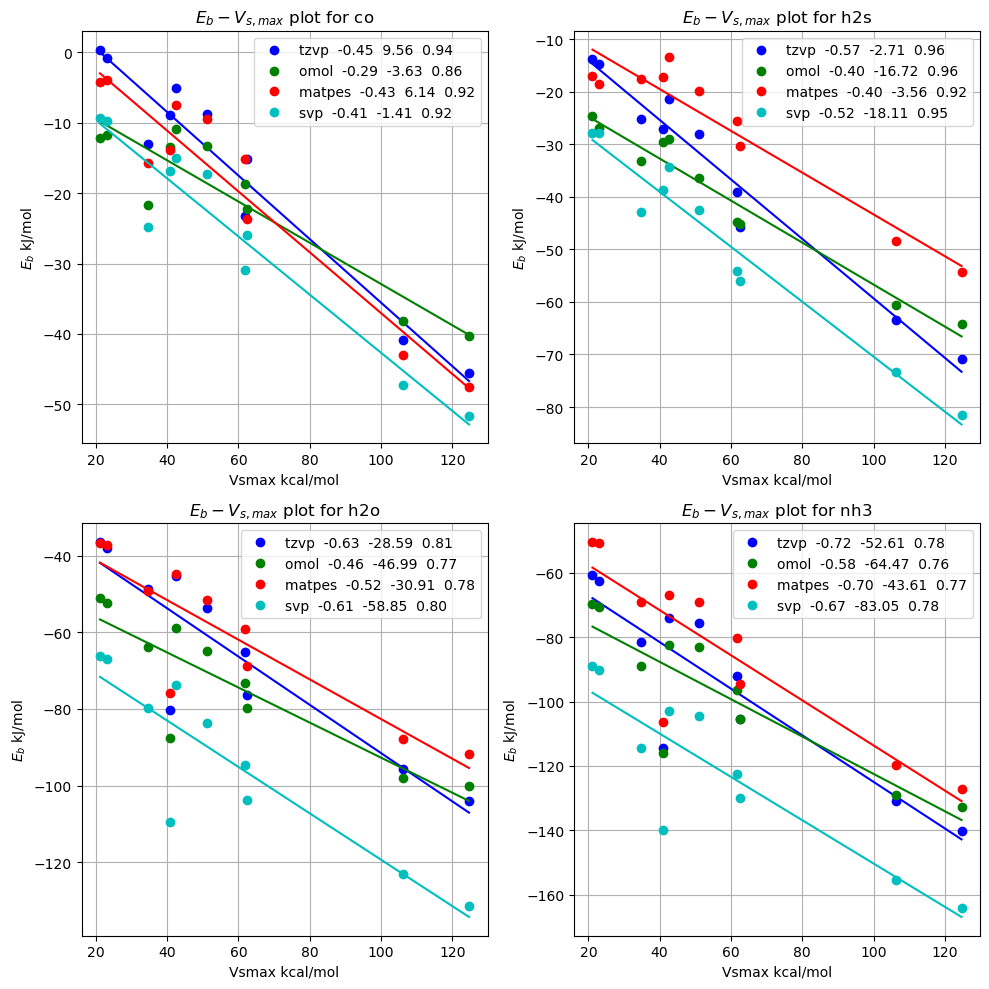

In [35]:
fig1 = plt.figure(1, figsize = (10,10))
gs = fig1.add_gridspec(2,2)

for i, df_ in enumerate(df_l):
    ix, iy = get_gs_position(i)

    grid_name = fig1.add_subplot(gs[iy, ix])
    grid_name.set_title(r"$E_{b} - V_{s,max}$ plot for " + f"{ads_l[i]}")

    slope_l, se_l = [], []
    for j, col_ in enumerate(["tzvp", "omol", "matpes", "svp"]):
        grid_name, slope, se = plot_with_regression(grid_name, j, df_["Vsmax"], df_[col_], col_, reginleg = True)
        slope_l.append(slope)
        se_l.append(se)

    grid_name.legend()
    grid_name.set_xlabel("Vsmax kcal/mol")
    grid_name.set_ylabel(r"$E_b$ kJ/mol")
    grid_name.grid(True)

    print("slope: ", slope_l)
    print("R2: ", se_l, "\n")

fig1.tight_layout()
fig1.savefig(general_save / "Eb_Vs_inh.pdf")
plt.show()

NOTE workflow: omol, matpes try all of configurations, and pick the lowest energy one. Then use omol optimized structure further opt by dft. Finally sp on all of them.\
dft: omol opt -> svp opt\
ref: omol opt -> svp opt -> tzvp sp (same structure as dft)\
two different configurations in matpes: co_06, h2s_14

###### E-Eref

slope:  [np.float64(0.6520831265304894), np.float64(0.9318445687664892), np.float64(0.9202481681608408)]
R2:  [np.float64(0.9205783263245734), np.float64(0.9284001316578674), np.float64(0.9915156891793683)] 

slope:  [np.float64(0.7013244655708567), np.float64(0.6923104082652485), np.float64(0.9237364995831301)]
R2:  [np.float64(0.9786401231098819), np.float64(0.9217338493974149), np.float64(0.9885407045135183)] 

slope:  [np.float64(0.7422559471214768), np.float64(0.8340667646159837), np.float64(0.9648697784332784)]
R2:  [np.float64(0.9903974758642855), np.float64(0.9946263074434889), np.float64(0.9983622436000248)] 

slope:  [np.float64(0.8122229567509927), np.float64(0.9755486799761448), np.float64(0.9292339833505179)]
R2:  [np.float64(0.995556028870976), np.float64(0.9936879041442473), np.float64(0.9932285580679413)] 



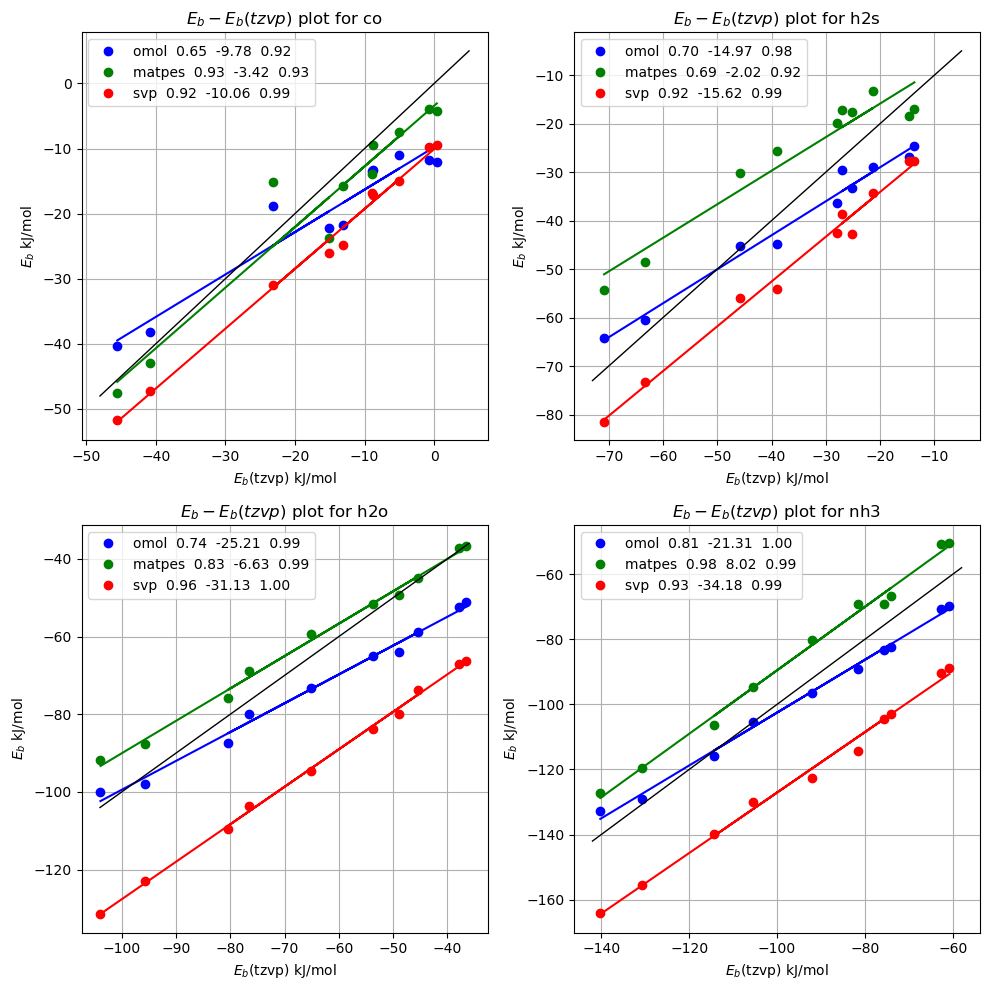

In [36]:
fig2 = plt.figure(1, figsize = (10,10))
gs = fig2.add_gridspec(2,2)

for i, df_ in enumerate(df_l):
    ix, iy = get_gs_position(i)

    grid_name = fig2.add_subplot(gs[iy, ix])
    grid_name.set_title(r"$E_{b} - E_{b}(tzvp)$ plot for " + f"{ads_l[i]}")

    xyrange = [(5., -48.), (-5., -73.), (-36., -104.), (-58., -142)]

    slope_l, se_l = [], []
    for j, col_ in enumerate(["omol", "matpes", "svp"]):
        grid_name, slope, se = plot_with_regression(grid_name, j, df_["tzvp"], df_[col_], col_, reginleg = True)
        slope_l.append(slope)
        se_l.append(se)

    xymin, xymax = xyrange[i]
    grid_name.plot([xymin, xymax], [xymin, xymax], linewidth=1, color="k")

    grid_name.legend()
    grid_name.set_xlabel(r"$E_b$(tzvp) kJ/mol")
    grid_name.set_ylabel(r"$E_b$ kJ/mol")
    grid_name.grid(True)

    print("slope: ", slope_l)
    print("R2: ", se_l, "\n")

fig2.tight_layout()
fig2.savefig(general_save / "Eb_Eb_inh.pdf")
plt.show()

### For sp energies

In [37]:
print(p_dict["sp energy"][1])
print(r_dict["sum sp energy"][1])

[[-329568.91632638 -329568.87423036 -329568.68805006 -329568.57833919
  -329568.52434908 -329568.50352965 -329568.54003917 -329568.55774562
  -329568.43430933 -329568.42534045]
 [-337352.48486958 -337352.40714569 -337352.21122644 -337352.14244966
  -337352.02098075 -337351.94215753 -337352.01349762 -337351.85570968
  -337351.83698824 -337351.80811696]
 [-328566.69336498 -328566.61259887 -328566.40900328 -328566.29718353
  -328566.17565204 -328566.09639616 -328566.46751048 -328566.11546589
  -328565.99182008 -328565.97995591]
 [-328026.54922727 -328026.45808545 -328026.18821653 -328026.05225212
  -328025.88550891 -328025.87324746 -328026.29022657 -328025.93530846
  -328025.72601753 -328025.71034649]]
[-329568.44325485 -337351.73821121 -328565.61023105 -328025.08409144]


In [38]:
print(p_dict["sp energy"][0])
print(r_dict["sum sp energy"][0])

[[-329569.12319005 -329569.07438371 -329568.81641433 -329568.89602668
  -329568.73348491 -329568.71018652 -329568.737036   -329568.7701577
  -329568.65123305 -329568.65160585]
 [-337352.6859726  -337352.60230031 -337352.42332014 -337352.35095146
  -337352.24936864 -337352.17437134 -337352.23081319 -337352.21612721
  -337352.08208664 -337352.06978437]
 [-328566.89951572 -328566.81626249 -328566.6176874  -328566.48867005
  -328566.39084784 -328566.30266935 -328566.66501344 -328566.33230799
  -328566.21679565 -328566.2024743 ]
 [-328026.74083352 -328026.65232304 -328026.38103913 -328026.24338489
  -328026.09461208 -328026.07790429 -328026.48154711 -328026.1483845
  -328025.94140381 -328025.92408105]]
[-329568.665488   -337351.95226184 -328565.82506111 -328025.30003137]


In [39]:
# svp opt + tzvp sp as ref
ref_dE = (p_dict["sp energy"][2] - np.array([r_dict["sum sp energy"][2]]).T) * eV_to_kJdmol
print(ref_dE)

# iteration over all opt energies
# p_dict=opt*ads*sites; r_dict=opt*ads->opt*ads*1
array_dE = (np.array(p_dict["sp energy"]) - r_dict["sum sp energy"].reshape(3,4,1)) * eV_to_kJdmol

f_dE = np.insert(array_dE, 0, ref_dE, axis=0)
print(f_dE.shape) # methods*abs*sites

x = r_dict["c vsmax"]

# Convert to df
df_l = []
col_l = ["Vsmax", "tzvp", "omol", "matpes", "svp"]
for i, ads_ in enumerate(ads_l):
    body = np.insert(f_dE[:,i,:], 0, x, axis=0)
    df_i = pd.DataFrame(body.T, columns=col_l)
    print(ads_)
    print(df_i)
    df_i.to_csv(general_save / f"df_{ads_}_sp.csv")
    df_l.append(df_i)

[[ -45.51795694  -40.85165766  -15.11599187  -23.21775653   -8.8147944
    -5.04457791   -8.94921994  -13.0502493    -0.76212657    0.37235152]
 [ -70.86613584  -63.39265309  -45.81021174  -39.01752086  -28.00670337
   -21.33189739  -27.06047354  -25.18297925  -14.66811851  -13.69064525]
 [-103.90838798  -95.66510893  -76.48137577  -65.14105816  -53.62351938
   -45.39809372  -80.36790186  -48.84563639  -37.93931376  -36.50579134]
 [-140.21959294 -130.73445289 -105.48292911  -92.05087649  -75.65279771
   -74.11504298 -114.29777927  -81.45961374  -62.66261656  -60.74390193]]
(4, 4, 10)
co
    Vsmax       tzvp       omol     matpes        svp
0  124.67 -45.517957 -44.161524 -45.644452 -45.517957
1  106.27 -40.851658 -39.452429 -41.582805 -40.851658
2   62.43 -15.115992 -14.562173 -23.619141 -15.115992
3   61.78 -23.217757 -22.243596 -13.033655 -23.217757
4   51.16  -8.814794  -6.560703  -7.824402  -8.814794
5   42.57  -5.044578  -4.312751  -5.815633  -5.044578
6   40.89  -8.949220  -6.903

slope:  [np.float64(1.0069795925470388), np.float64(0.9956961811204683)]
R2:  [np.float64(0.9976913226606835), np.float64(0.9246448433242896)] 

slope:  [np.float64(1.0166468966566706), np.float64(1.1405735872153064)]
R2:  [np.float64(0.9978446556949814), np.float64(0.9716166527246997)] 

slope:  [np.float64(0.9962935049402623), np.float64(1.0228971171834396)]
R2:  [np.float64(0.9994009090888605), np.float64(0.9986454138301031)] 

slope:  [np.float64(0.988084153559975), np.float64(1.0183520666877883)]
R2:  [np.float64(0.9992472612114599), np.float64(0.9991857238867379)] 



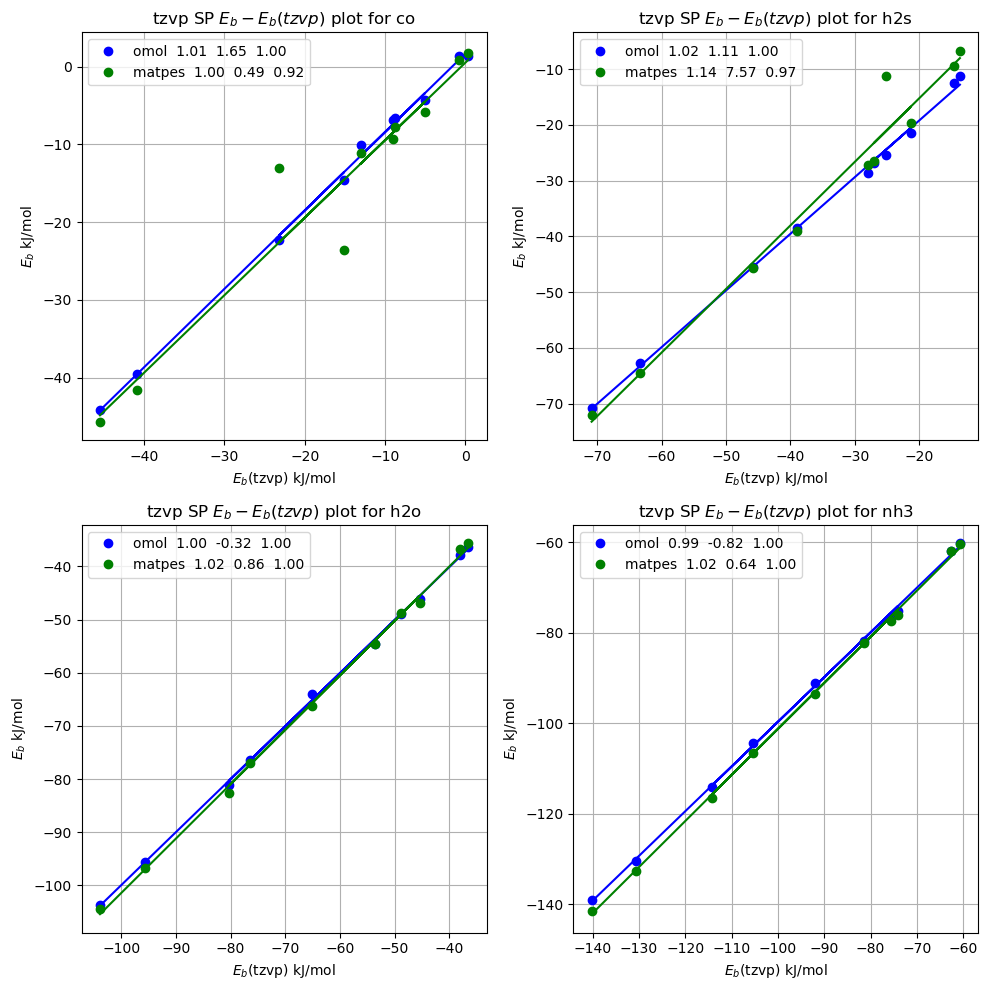

In [40]:
fig3 = plt.figure(1, figsize = (10,10))
gs = fig3.add_gridspec(2,2)

for i, df_ in enumerate(df_l):
    ix, iy = get_gs_position(i)

    grid_name = fig3.add_subplot(gs[iy, ix])
    grid_name.set_title(r"tzvp SP $E_{b} - E_{b}(tzvp)$ plot for " + f"{ads_l[i]}")

    slope_l, se_l = [], []
    for j, col_ in enumerate(["omol", "matpes"]):
        grid_name, slope, se = plot_with_regression(grid_name, j, df_["tzvp"], df_[col_], col_, reginleg = True)
        slope_l.append(slope)
        se_l.append(se)

    grid_name.legend()
    grid_name.set_xlabel(r"$E_b$(tzvp) kJ/mol")
    grid_name.set_ylabel(r"$E_b$ kJ/mol")
    grid_name.grid(True)

    print("slope: ", slope_l)
    print("R2: ", se_l, "\n")

fig3.tight_layout()
fig3.savefig(general_save / "Eb_Eb_sp.pdf")
plt.show()